Understanding the Distance metrics and Introduction to KNN

In [1]:
import numpy as np
import pandas as pd
import math
from scipy.spatial import distance
import matplotlib.pyplot as plt

In [2]:
x_1= np.array((1,2))
x_2=np.array((4,6))

In [5]:
sumv=0
for i in range(len(x_1)):
  sumv+=((x_1[i]-x_2[i])**2)
k=math.sqrt(sumv)
print(k)

5.0


TASK 1

In [6]:
euclidean_dist=np.linalg.norm(x_1-x_2)
print(euclidean_dist)

5.0


In [7]:
# 3-D Visualization
plotx = np.linspace(-10,10,50)
meshx, meshy = np.meshgrid(plotx,plotx)

In [8]:
tempeuclid = np.sqrt((meshx**2 + meshy**2))

In [9]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=tempeuclid, x=plotx, y=plotx)])
fig.update_layout(title='Euclidean Distance from origin', autosize=False,
                  width=1000, height=1000,
                  margin=dict(l=65, r=50, b=65, t=90))
fig.show()

Manhattan Distance

In [10]:
manhattan_dist = distance.cityblock(x_1, x_2)
print(manhattan_dist)

7


TASK 2

In [12]:
manhattan_dist=np.linalg.norm(x_1-x_2,ord=1)
print(manhattan_dist)

7.0


In [13]:
#3d Visualisation

In [14]:
plotx=np.linspace(-10,10,50)
meshx,meshy=np.meshgrid(plotx,plotx)

In [20]:
tempmanhattan = np.abs(meshx) + np.abs(meshy)

In [21]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=tempmanhattan, x=plotx, y=plotx)])
fig.update_layout(title='Manhattan Distance from origin', autosize=False,
                  width=1000, height=1000,
                  margin=dict(l=65, r=50, b=65, t=90))
fig.show()

Minkowski Distance

In [22]:
minkowski_distance = distance.minkowski(x_1, x_2, p=3)
print("Minkowski distance when p=3 is ",minkowski_distance)

Minkowski distance when p=3 is  4.497941445275415


In [23]:
minkowski_dist_p1 = distance.minkowski(x_1,x_2,p=1)
print("Minkowski distance when p=1 is ",minkowski_dist_p1)
minkowski_dist_p2 = distance.minkowski(x_1,x_2,p=2)
print("Minkowski distance when p=2 is ",minkowski_dist_p2)

Minkowski distance when p=1 is  7.0
Minkowski distance when p=2 is  5.0


Hashing distance

In [24]:
str_1 = 'euclidean'
str_2 = 'manhattan'
hamming_dist = distance.hamming(list(str_1), list(str_2)) * len(str_1)
print(hamming_dist)

7.0


Cosine Similarity

In [26]:
from numpy.linalg import norm
cosine_similarity = 1 - distance.cosine(x_1,x_2)
print(cosine_similarity)

cosine_similarity = np.dot(x_1, x_2)/(norm(x_1)*norm(x_2))
print(cosine_similarity)

0.9922778767136677
0.9922778767136677


Chebysehev Distance

In [27]:
chebyshev_distance = distance.chebyshev(x_1,x_2)
print(chebyshev_distance)

4


Jaccard Distance

In [28]:
print(distance.jaccard([1, 0, 0], [0, 1, 0]))
print(distance.jaccard([1, 0, 0], [1, 1, 0]))
print(distance.jaccard([1, 0, 0], [1, 1, 1]))

1.0
0.5
0.6666666666666666


In [29]:
def jaccard_similarity(a, b):
    c = a.intersection(b)
    return float(len(c)) / (len(a) + len(b) - len(c))

list1 = ['dog', 'cat', 'rat']
list2 = ['dog', 'cat', 'mouse', 'rabbit']
# The intersection is ['dog', 'cat']
# union is ['dog', 'cat', 'rat', 'mouse, 'rabbit']
words1 = set(list1)
words2 = set(list2)
print("Jaccard similarity is :",jaccard_similarity(words1, words2))
print("Jaccard distance is :", 1-jaccard_similarity(words1, words2))

Jaccard similarity is : 0.4
Jaccard distance is : 0.6


Haversine Distance

In [30]:
def haversine(coord1, coord2):

    # Coordinates in decimal degrees (e.g. 2.89078, 12.79797)
    lon1, lat1 = coord1
    lon2, lat2 = coord2

    R = 6371000  # radius of Earth in meters
    phi_1 = math.radians(lat1)
    phi_2 = math.radians(lat2)

    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = math.sin(delta_phi / 2.0) ** 2 + math.cos(phi_1) * math.cos(phi_2) * math.sin(delta_lambda / 2.0) ** 2

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    meters = R * c  # output distance in meters
    km = meters / 1000.0  # output distance in kilometers

    meters = round(meters, 3)
    km = round(km, 3)


    print(f"Distance: " + str(km) + " km")

First off, KNN is a **supervised learning** algorithm, ie, the idea is to learn a function that can map an input to an output given some example pairs.


### What is KNN ?

K-NN (K- Nearest Neighbours) is a classification technique where the output is a class membership.  
An object is classified by a **plurality vote of its neighbors**, with the object being assigned to the class most common among its k nearest neighbors (k is a positive integer, typically small). If k = 1, then the object is simply assigned to the class of that single nearest neighbor.  

### What is so unique about KNN ?  
First off, KNN is a **supervised learning** algorithm, ie, the idea is to learn a function that can map an input to an output given some example pairs.  

It is a **non-parametric** algorithm, since it doesn't assume anything about the form of the mapping function, which makes it very flexible to use. Certain algorithms are parametric (such as Naive Bayes), which are constrained as they require a specified form. KNN can, thus, be a good algorithm to try if the form is unknown.  

Moreover, KNN is an **instance-based algorithm**, since it compares new problems/inputs with those which were seen during model training and that were stored in memory.

In [31]:
import random
import scipy.stats as ss
from sklearn.neighbors import KNeighborsClassifier

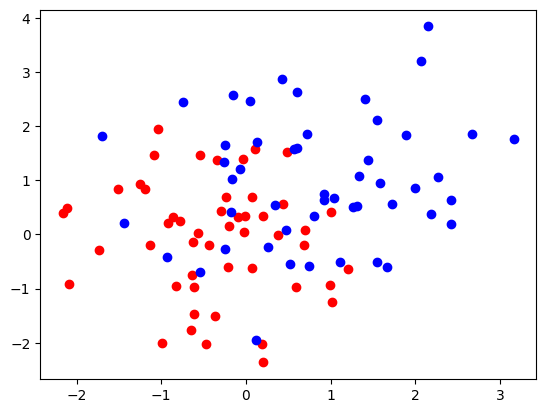

In [32]:
def generate_synth_data(n = 50):
    points = np.concatenate((ss.norm(0, 1).rvs((n, 2)), ss.norm(1, 1).rvs((n, 2))), axis = 0)
    outcomes = np.concatenate((np.repeat(0, n), np.repeat(1, n)))
    return (points, outcomes)

n = 50
pts,tgts = generate_synth_data(n) #generates 100 points
# print(tgts)
plt.figure()
plt.plot(pts[:n, 0], pts[:n, 1], "ro")
plt.plot(pts[n:, 0], pts[n:, 1], "bo")
plt.show()

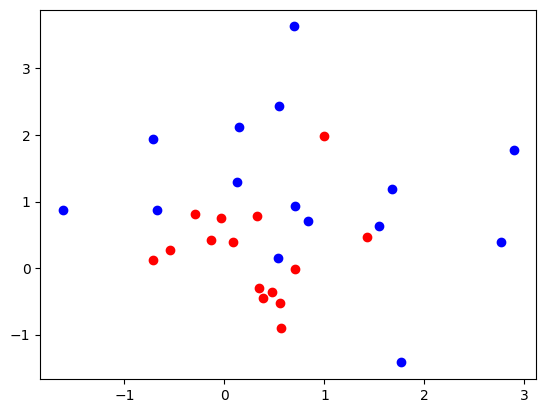

In [33]:
n = 15
test_pts,test_tgts = generate_synth_data(n)
# print(test_tgts)
plt.figure()
plt.plot(test_pts[:n, 0], test_pts[:n, 1], "ro")
plt.plot(test_pts[n:, 0], test_pts[n:, 1], "bo")
plt.show()

**TASK** **3**

In [34]:
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

knn.fit(pts, tgts)

our_predictions = knn.predict(test_pts)

print("Prediction Accuracy:")
print(100 * np.mean(our_predictions == test_tgts))

Prediction Accuracy:
56.666666666666664


In [35]:
knn = KNeighborsClassifier(n_neighbors=3, metric='manhattan')

knn.fit(pts, tgts)

our_predictions = knn.predict(test_pts)

print("Prediction Accuracy:")
print(100 * np.mean(our_predictions == test_tgts))

Prediction Accuracy:
63.33333333333333


In [36]:
knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski',p=2)

knn.fit(pts, tgts)

our_predictions = knn.predict(test_pts)

print("Prediction Accuracy:")
print(100 * np.mean(our_predictions == test_tgts))

Prediction Accuracy:
56.666666666666664


In [37]:
knn = KNeighborsClassifier(n_neighbors=3, metric='chebyshev')

knn.fit(pts, tgts)

our_predictions = knn.predict(test_pts)

print("Prediction Accuracy:")
print(100 * np.mean(our_predictions == test_tgts))

Prediction Accuracy:
56.666666666666664


In [38]:
knn = KNeighborsClassifier(n_neighbors=3, metric='hamming')

knn.fit(pts, tgts)

our_predictions = knn.predict(test_pts)

print("Prediction Accuracy:")
print(100 * np.mean(our_predictions == test_tgts))

Prediction Accuracy:
50.0


In [39]:
from sklearn.datasets import load_iris
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
# data['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
data['target'] = pd.Series(iris.target)
data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [40]:
np.random.seed(123)
indices = np.random.permutation(data.shape[0])
div = int(0.65 * len(indices))
train_idx, test_idx = indices[:div], indices[div:]

train_set, test_set = data.loc[train_idx,:], data.loc[test_idx,:]
test_class = list(test_set.iloc[:,-1])
train_class = list(train_set.iloc[:,-1])

In [41]:
def dist_euclidean(X1,X2):
    return distance.euclidean(X1,X2)

In [42]:
def dist_cosine(X1,X2):
    return distance.cosine(X1,X2)

In [43]:
def dist_manhattan(X1,X2):
    return distance.cityblock(X1,X2)

In [44]:
def dist_chebyshev(X1,X2):
    return distance.chebyshev(X1,X2)

In [45]:
metrics_list = [dist_euclidean,dist_cosine, dist_manhattan, dist_chebyshev]
for dist_metric in metrics_list:
  knn = KNeighborsClassifier(n_neighbors = 3, metric=dist_metric)
  knn.fit(train_set, train_class)
  our_predictions = knn.predict(test_set)
  print(dist_metric.__name__)
  print("Prediction Accuracy: ")
  print(100 * np.mean(our_predictions == test_class))
  print()

dist_euclidean
Prediction Accuracy: 
100.0

dist_cosine
Prediction Accuracy: 
100.0

dist_manhattan
Prediction Accuracy: 
100.0

dist_chebyshev
Prediction Accuracy: 
100.0



TASK 1.1

In [46]:
def minkowski_distance(x1, x2, p):
    """
    Calculate Minkowski distance between two points.
    """

    return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)


# Test your implementation
x_1 = np.array([1, 2, 3])
x_2 = np.array([4, 6, 8])

# Test with p=1 (Manhattan)
print("Minkowski distance (p=1):", minkowski_distance(x_1, x_2, 1))
print("Manhattan distance:", distance.cityblock(x_1, x_2))
print()

# Test with p=2 (Euclidean)
print("Minkowski distance (p=2):", minkowski_distance(x_1, x_2, 2))
print("Euclidean distance:", distance.euclidean(x_1, x_2))

Minkowski distance (p=1): 12.0
Manhattan distance: 12

Minkowski distance (p=2): 7.0710678118654755
Euclidean distance: 7.0710678118654755


TASK 2

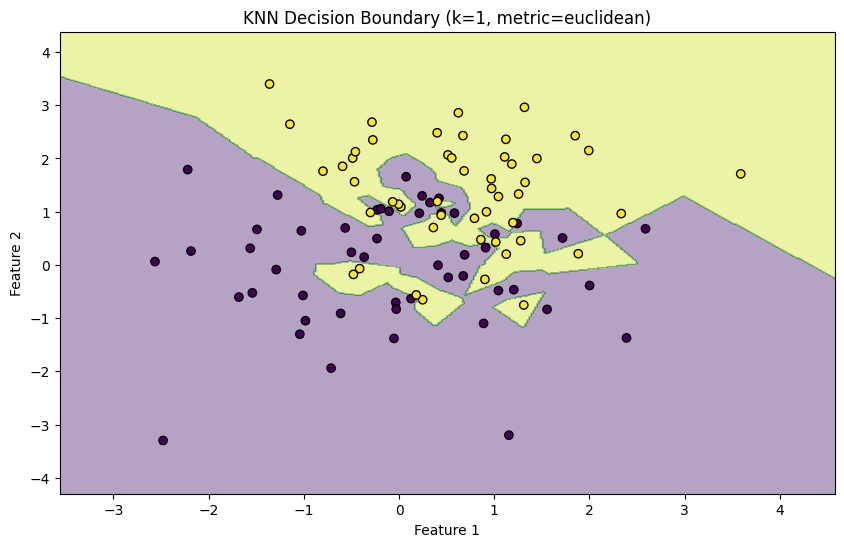

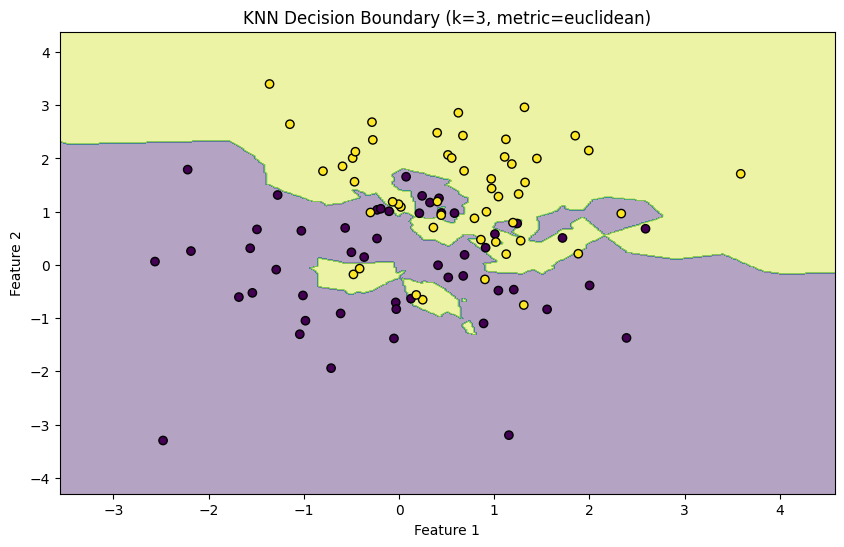

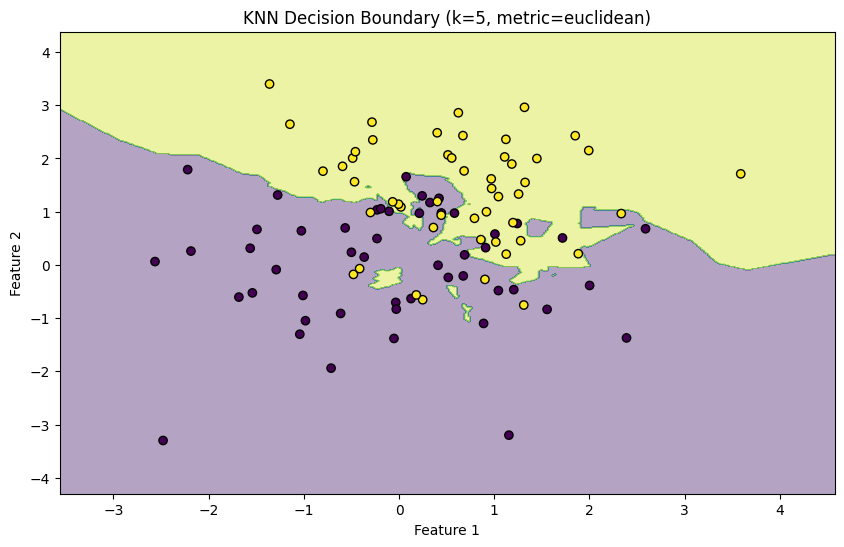

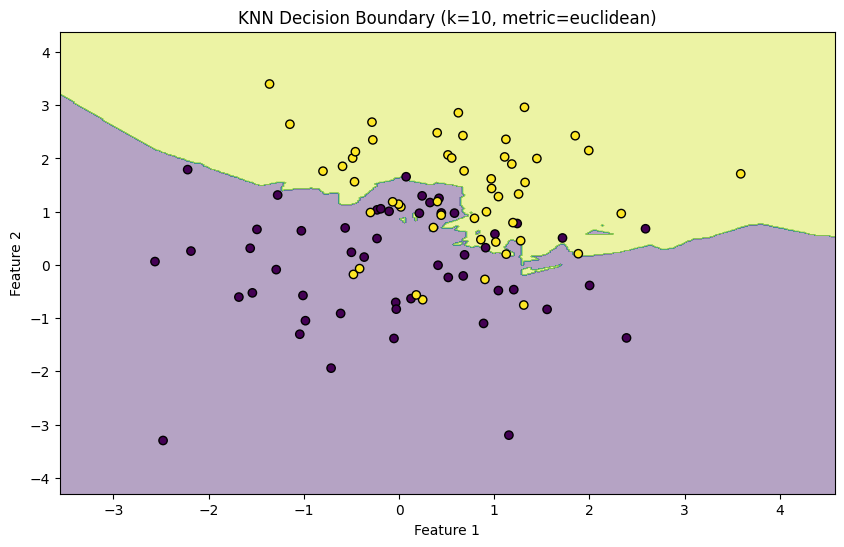

In [47]:
def plot_decision_boundary(X, y, k_value, metric='euclidean'):
    """
    Plot the decision boundary for KNN classifier.
    """

    # Create a mesh grid
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Train KNN classifier
    knn = KNeighborsClassifier(
        n_neighbors=k_value,
        metric=metric
    )

    knn.fit(X, y)

    # Predict for each point in mesh
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

    # Reshape predictions to match mesh grid
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and training points
    plt.figure(figsize=(10, 6))

    plt.contourf(xx, yy, Z, alpha=0.4)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors='k'
    )

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    plt.title(
        f'KNN Decision Boundary (k={k_value}, metric={metric})'
    )

    plt.show()


# Generate synthetic data
n = 50
pts, tgts = generate_synth_data(n)

# Test with different k values
for k in [1, 3, 5, 10]:
    plot_decision_boundary(pts, tgts, k)

As K increases, the decision boundary becomes smoother.
Small K (like k=1) is highly sensitive to individual points, creating very irregular and complex boundaries → overfitting.
Larger K considers more neighbors, so predictions become more stable and smoother.

Usually:
k=1 → overfits
Very large K → underfits
Moderate values like k=3 or k=5 often generalize better.

Effect on boundary:

Boundaries become more box-like / diamond-shaped
Distance is measured along horizontal and vertical directions

Euclidean → circular influence regions
Manhattan → square/diamond influence regions

The overall classification may stay similar, but boundary shapes slightly change

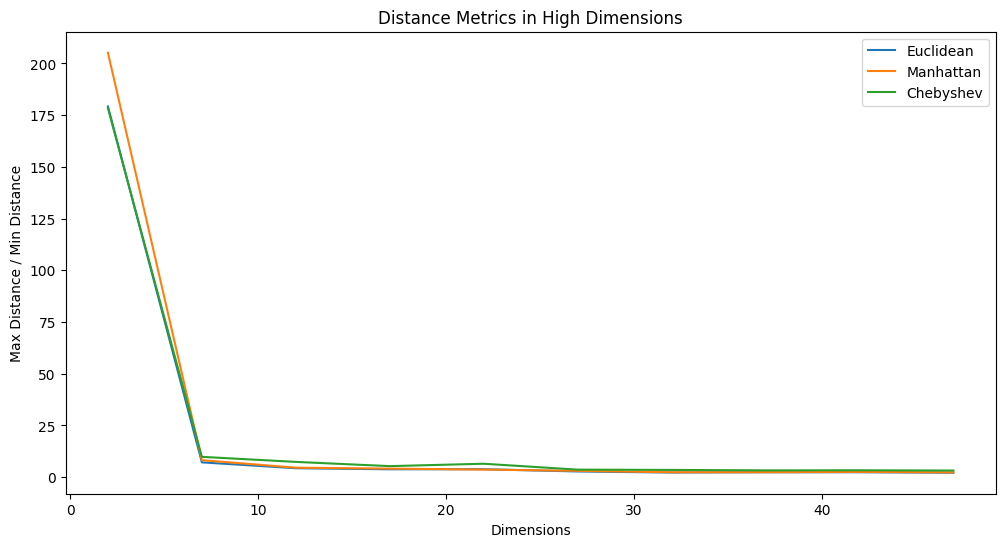

In [48]:
from scipy.spatial import distance
import matplotlib.pyplot as plt
import numpy as np

def analyze_distance_in_high_dims(max_dim=50, n_points=100):

    dimensions = range(2, max_dim + 1, 5)

    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:

        # Generate random points
        points = np.random.randn(n_points, dim)

        # Compute pairwise distances
        euclidean_dists = distance.pdist(points, metric='euclidean')
        manhattan_dists = distance.pdist(points, metric='cityblock')
        chebyshev_dists = distance.pdist(points, metric='chebyshev')

        # Calculate ratio max/min
        euclidean_ratio = np.max(euclidean_dists) / np.min(euclidean_dists)

        manhattan_ratio = np.max(manhattan_dists) / np.min(manhattan_dists)

        chebyshev_ratio = np.max(chebyshev_dists) / np.min(chebyshev_dists)

        # Store results
        results['euclidean'].append(euclidean_ratio)
        results['manhattan'].append(manhattan_ratio)
        results['chebyshev'].append(chebyshev_ratio)

    # Plot results
    plt.figure(figsize=(12, 6))

    plt.plot(dimensions, results['euclidean'], label='Euclidean')

    plt.plot(dimensions, results['manhattan'], label='Manhattan')

    plt.plot(dimensions, results['chebyshev'], label='Chebyshev')

    plt.xlabel('Dimensions')
    plt.ylabel('Max Distance / Min Distance')

    plt.title('Distance Metrics in High Dimensions')

    plt.legend()

    plt.show()

    return results


# Run the analysis
results = analyze_distance_in_high_dims()